## Práctica 10: Procesamiento Multidominio para Inspección de Calidad Industrial.
### Autor: Juan Manuel Mena Hernandez
### Fecha: 14-05-2026

### EJERCICIO. PIPELINE DE INSPECCIÓN AUTOMÁTICA DE PIEZAS CIRCULARES

En un entorno industrial real, las imágenes capturadas por sistemas de inspección automática pueden presentar dos tipos de degradación: ruido periódico, causado por interferencias eléctricas y que se manifiesta como un patrón de rayas diagonales, y ruido gaussiano, producido por la sensibilidad del sensor. 

El objetivo de este ejercicio es desarrollar un pipeline capaz de limpiar dicha imagen sintética, detectar automáticamente las piezas circulares presentes y contarlas. 

Para ello se encadenan cuatro etapas: filtrado frecuencial mediante la Transformada de Fourier (FFT) para eliminar el ruido periódico, filtrado espacial gaussiano para suavizar el ruido residual, umbralización automática con el método de Otsu para binarizar la imagen, y análisis de contornos con bounding boxes para localizar y contar las piezas válidas.

Piezas detectadas: 3


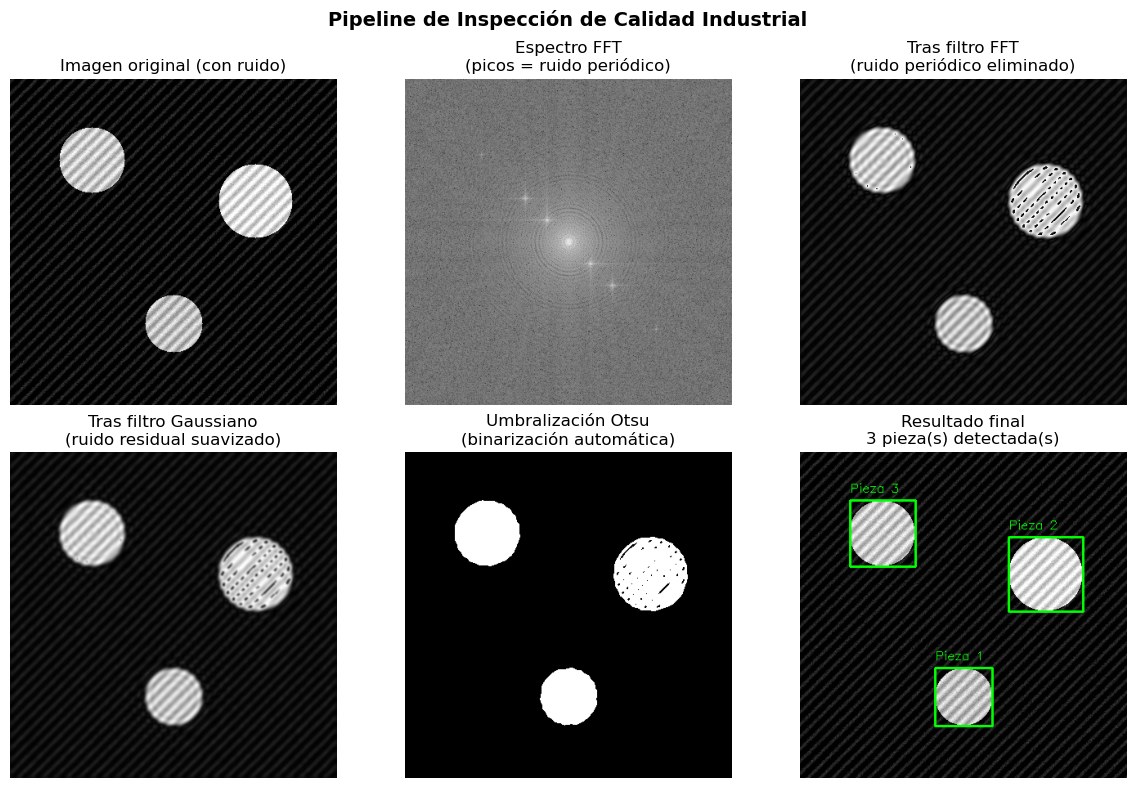

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── GENERACIÓN DE LA IMAGEN SINTÉTICA ────────────────────────────────────────
# Tres círculos de distinto tamaño simulan piezas en una línea de ensamblaje.
# Se añade ruido periódico (rayas diagonales por interferencia eléctrica)
# y ruido gaussiano (granulado del sensor).
def generar_imagen():
    img = np.zeros((400, 400), dtype=np.uint8)
    cv2.circle(img, (100, 100), 40, 200, -1)
    cv2.circle(img, (300, 150), 45, 220, -1)
    cv2.circle(img, (200, 300), 35, 190, -1)
    x, y = np.meshgrid(np.arange(400), np.arange(400))
    ruido_per   = 40 * np.sin(2 * np.pi * (x + y) / 15)
    ruido_gauss = np.random.normal(0, 10, (400, 400))
    return np.clip(img + ruido_per + ruido_gauss, 0, 255).astype(np.uint8)

img = generar_imagen()

# ── ETAPA 1: FILTRADO FRECUENCIAL (FFT) ──────────────────────────────────────
# La FFT descompone la imagen en componentes de frecuencia.
# El ruido periódico aparece como picos alejados del centro en el espectro.
f      = np.fft.fft2(img)
fshift = np.fft.fftshift(f)          # centrar la componente DC (frecuencia cero)

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Máscara circular pasa-bajo: conserva bajas frecuencias (formas)
# y elimina altas frecuencias (ruido periódico de las rayas diagonales)
mask = np.zeros((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), 50, 1, -1)

fshift_filtrado = fshift * mask

# Transformada inversa: volver al dominio espacial
f_ishift = np.fft.ifftshift(fshift_filtrado)
img_fft  = np.abs(np.fft.ifft2(f_ishift)).astype(np.uint8)

# ── ETAPA 2: FILTRADO ESPACIAL (GAUSSIANO) ───────────────────────────────────
# Suaviza el ruido gaussiano residual manteniendo los bordes principales.
blur = cv2.GaussianBlur(img_fft, (5, 5), 0)

# ── ETAPA 3: UMBRALIZACIÓN AUTOMÁTICA (OTSU) ─────────────────────────────────
# Otsu calcula automáticamente el umbral óptimo que maximiza la separación
# entre el fondo (negro) y los objetos (piezas circulares).
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ── ETAPA 4: SEGMENTACIÓN Y CONTEO DE PIEZAS ─────────────────────────────────
# Se detectan contornos externos y se filtran por área mínima (> 100 px²)
# para descartar artefactos pequeños causados por ruido residual.
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output   = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
contador = 0

for cnt in contours:
    if cv2.contourArea(cnt) > 100:
        contador += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(output, f"Pieza {contador}", (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

print(f"Piezas detectadas: {contador}")

# ── VISUALIZACIÓN ─────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Imagen original (con ruido)")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(fshift)), cmap='gray')
plt.title("Espectro FFT\n(picos = ruido periódico)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_fft, cmap='gray')
plt.title("Tras filtro FFT\n(ruido periódico eliminado)")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(blur, cmap='gray')
plt.title("Tras filtro Gaussiano\n(ruido residual suavizado)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(thresh, cmap='gray')
plt.title("Umbralización Otsu\n(binarización automática)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado final\n{contador} pieza(s) detectada(s)")
plt.axis('off')

plt.suptitle("Pipeline de Inspección de Calidad Industrial", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El pipeline aplica cuatro etapas encadenadas para limpiar la imagen y detectar las piezas. 

La FFT transforma la imagen al dominio frecuencial, donde el ruido periódico se manifiesta como picos alejados del centro.
Luego una máscara circular paso-bajo los elimina y la transformada inversa recupera la imagen limpia, que posteriormente se suaviza con un filtro gaussiano para reducir el ruido residual. 

El método de Otsu binariza automáticamente la imagen calculando el umbral óptimo entre fondo y objetos, y el análisis de contornos localiza y etiqueta cada pieza filtrando por área mínima para descartar objetos insignificantes, mostrando en la figura las seis etapas del proceso junto con el número de piezas detectadas.